Mia Kim  
Professor Alex Chisholm  
90-819 Python Programming II  
# Impact of Socioeconomic Factors on Overall Self-Reported Health


## Executive Summary

The [Centers for Disease Control and Prevention's Behavioral Risk Factor Surveillance System](https://www.cdc.gov/brfss/) is the world’s largest ongoing health-related survey, capturing data from more than 400,000 respondents annually across over 100 health and behavioral factors. 

This analysis uses data from the 2015 BRFSS to examine whether variables related to demographic, socioeconomic, and healthcare access characteristics have measurable effects on self-reported overall health ratings. A multiple linear regression, correlation matrix, and several visualizations were used to explore these relationships.

The regression model explained 29.3% of the variation in self-reported overall health, identifying employment, income, cost barriers, and disability status as significant predictors. Respondents who are employed, face fewer cost barriers, and are not disabled reported better overall health. Moderate correlations were also found between income and education (R = 0.45) and between overall health and disability (R = -0.44).

Future analyses could build on this work by utilizing the complete BRFSS dataset across multiple years to include cross-sectional and longitudinal insights. Additionally, integrating additional socioeconomic, social context, and geographical variables could offer a more comprehensiv understanding of how these factors influence self-reported health.

## Introduction and Methodology
### Research Question and Objectives
**Do socioeconomic factors have measurable effects on self-reported overall health ratings?**
My analysis aimed to answer three objectives:
1. To examine whether socioeconomic factors—such as income, employment, education, and cost barriers—significantly influence self-reported overall health.
2. To assess relationships between demographic, socioeconomic, and health access variables using correlation and regression analyses.
3. To identify which socioeconomic indicators most strongly predict variations in self-reported health status.

### Data Sources and Collection
The data used in this analysis were obtained from the 2015 [Centers for Disease Control and Prevention's Behavioral Risk Factor Surveillance System](https://www.cdc.gov/brfss/) and uploaded to [Kaggle](https://www.kaggle.com/datasets/cdc/behavioral-risk-factor-surveillance-system/data). The original data contained 441,456 respondents and 330 variables. After data cleaning, 300,871 respondents and 11 variables remained. The variables and data cleaning process are shown below.

### Variables Used in Analysis 
`overall_health`: Self-reported overall health on a Likert-type scale (1 = Excellent, 2 = Very Good, 3 = Good, 4 = Fair, 5 = Poor)

`state`: U.S. state of residence (excluding DC, Guam, and Puerto Rico), coded alphabetically (1 = Alabama, 50 = Wyoming)

`sex`: Sex of the survey respondent (1 = Male, 2 = Female)

`education`: Highest level of education completed 
- 1 = None
- 2 = Elementary
- 3 = Some High School
- 4 = High School/GED
- 5 = Some College or 2-year institutions
- 6 = College

`homeowner`: Ownership of residence (1 = Own, 2 = Rent, 3 = Other)

`employment`: Employment status of respondent, where "unemployed" includes retirement, disability, and student status (1 = Employed, 2 = Unemployed)

`income`: Annual household income level
- 1 = Less than \\$10,000
- 2 = Between \\$10,000 and \\$15,000
- 3 = Between \\$15,000 and \\$20,000
- 4 = Between \\$20,000 and \\$25,000
- 5 = Between \\$25,000 and \\35,000
- 6 = Between \\$35,000 and \\50,000
- 7 = Between \\$50,000 and \\75,000
- 8 = \\$75,000 or more

`health_coverage`: Whether respondents have any form of health coverage (eg. private insurance, HMOs or prepaid plans, Medicare, Indian Health Service) (1 = Yes, 2 = No)

`cost`: Whether respondents needed medical care in the last year but were unable to afford it (1 = Yes, 2 = No)

`disability_gen`: Whether the respondent is limited in any way in usual activities due to physical, mental, or emotional problems (1 = Yes, 2 = No)

#### Data Preparation and Cleaning
The original BRFSS dataset included 441,456 respondents and 330 variables. Records with missing or invalid responses for key variables (e.g., income, overall health, disability status) were removed. Variables irrelevant to the analysis were excluded, resulting in a final sample of 300,871 respondents and 11 variables.

Categorical variables were recoded numerically for consistency, and missing codes (e.g., 7, 9, 99) were replaced with NaN values per BRFSS documentation. After cleaning, all rows containing NaN values were dropped to ensure valid model input.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# read dataset
df_raw = pd.read_csv("2015.csv")

# select and rename columns
df_clean = (df_raw[['SEQNO', '_STATE', 'SEX', 'EDUCA', 'RENTHOM1', 'EMPLOY1', 'INCOME2',
                    'GENHLTH', 'HLTHPLN1', 'MEDCOST', 'QLACTLM2', 'DISPCODE', 'CSTATE', 'STATERES']]
                    .rename(columns={
                        'SEQNO': 'id',
                        '_STATE': 'state',
                        'EDUCA': 'education',
                        'RENTHOM1': 'homeowner',
                        'EMPLOY1': 'employment',
                        'INCOME2': 'income',
                        'GENHLTH': 'overall_health',
                        'HLTHPLN1': 'health_coverage',
                        'MEDCOST': 'cost',
                        'QLACTLM2': 'disability_gen'})
                    .query("DISPCODE == 1100 and (CSTATE == 1 or STATERES == 1)")

                    # remove unwanted columns after filtering
                    .drop(columns=['DISPCODE', 'CSTATE', 'STATERES'])
                    
                    # relevel and remove specified unknown or missing data 
                    .assign(
                        state = lambda d:d['state'].replace({11: None, 66: None, 72: None}),
                        education = lambda d:d['education'].replace({9: None}),
                        homeowner = lambda d:d['homeowner'].replace({7: None, 9: None}),
                        employment = lambda d:d['employment'].replace({2: 1, 3: 2, 4: 2, 5: 2, 6: 2, 7: 2, 8: 2, 9: None}),
                        income = lambda d:d['income'].replace({77: None, 99: None}),
                        overall_health = lambda d:d['overall_health'].replace({7: None, 9: None}),
                        health_coverage = lambda d:d['health_coverage'].replace({7: None, 9:None}),
                        cost = lambda d:d['cost'].replace({7: None, 9: None}),
                        disability_gen = lambda d:d['disability_gen'].replace({7: None, 9: None}))

                    # remove all NA values
                    .dropna()
            )

# relevel `state` column to be 1-50 due to skipped numbers in raw data
df_clean['state'] = pd.factorize(df_clean['state'])[0] + 1
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')

# ensure column name and type uniformity
df_clean.columns = df_clean.columns.str.lower()
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')

# preview first few rows and calculate total columns and rows
print('Total raw rows:', len(df_raw))
print('Total raw columns:', len(df_raw.columns))
print(df_clean.head())
print('Total clean rows:', len(df_clean))
print('Total clean columns:', len(df_clean.columns))

Total raw rows: 441456
Total raw columns: 330
             id  state  sex  education  homeowner  employment  income  \
1  2.015000e+09      1  2.0        6.0        1.0         2.0     1.0   
3  2.015000e+09      1  2.0        4.0        1.0         2.0     8.0   
5  2.015000e+09      1  2.0        3.0        1.0         1.0     6.0   
6  2.015000e+09      1  2.0        5.0        1.0         2.0     4.0   
7  2.015000e+09      1  1.0        3.0        1.0         2.0     3.0   

   overall_health  health_coverage  cost  disability_gen  
1             3.0              2.0   1.0             1.0  
3             5.0              1.0   1.0             1.0  
5             2.0              1.0   2.0             1.0  
6             2.0              1.0   2.0             2.0  
7             5.0              1.0   1.0             1.0  
Total clean rows: 300871
Total clean columns: 11


#### Data Visualizations
Prior to modeling, descriptive analyses were conducted to summarize key demographic and socioeconomic characteristics. The sample was evenly distributed by sex, with the majority of respondents reporting at least a high school education. Most respondents were employed and had health coverage, though income levels were skewed toward lower brackets.

The below 9-panel figure illustrates the distribution of categorical variables across the sample.

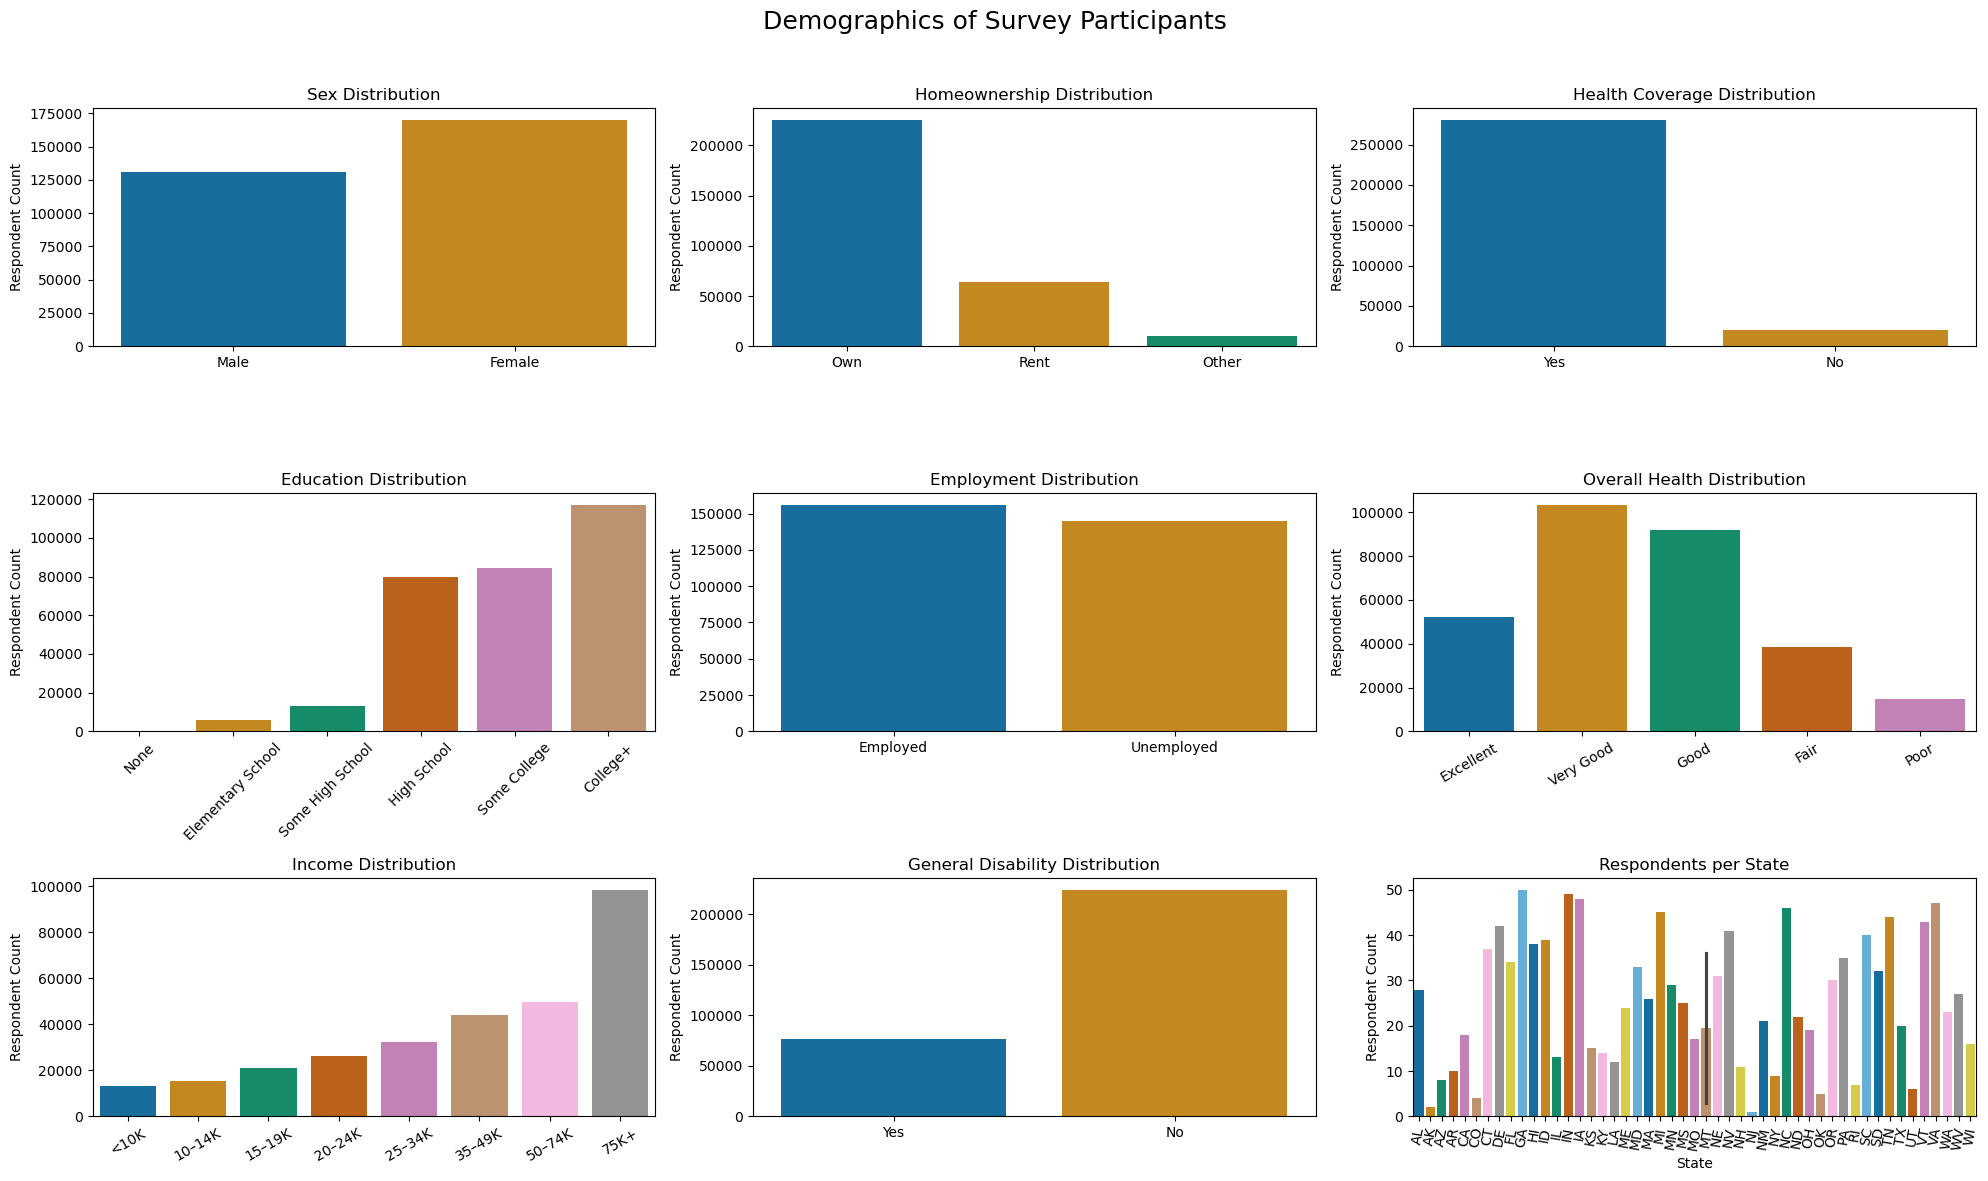

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(20, 12))
fig.suptitle("Demographics of Survey Participants", fontsize=18)
plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)

# Sex Distribution
sns.countplot(data=df_clean, x='sex', ax=axes[0, 0], palette='colorblind')
axes[0, 0].set_title("Sex Distribution")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Respondent Count")
axes[0, 0].set_xticks(axes[0, 0].get_xticks())
axes[0, 0].set_xticklabels(['Male', 'Female'])

# Education Distribution
sns.countplot(data=df_clean, x='education', ax=axes[1, 0], palette='colorblind')
axes[1, 0].set_title("Education Distribution")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Respondent Count")
axes[1, 0].set_xticks(axes[1, 0].get_xticks())
axes[1, 0].set_xticklabels(['None', 'Elementary School', 'Some High School',
                            'High School', 'Some College', 'College+'], rotation=45)

# Homeownership Distribution
sns.countplot(data=df_clean, x='homeowner', ax=axes[0, 1], palette='colorblind')
axes[0, 1].set_title("Homeownership Distribution")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Respondent Count")
axes[0, 1].set_xticks(axes[0, 1].get_xticks())
axes[0, 1].set_xticklabels(['Own', 'Rent', 'Other'])

# Employment Distribution
sns.countplot(data=df_clean, x='employment', ax=axes[1, 1], palette='colorblind')
axes[1, 1].set_title("Employment Distribution")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Respondent Count")
axes[1, 1].set_xticks(axes[1, 1].get_xticks())
axes[1, 1].set_xticklabels(['Employed', 'Unemployed'])

# Income Distribution
sns.countplot(data=df_clean, x='income', ax=axes[2, 0], palette='colorblind')
axes[2, 0].set_title("Income Distribution")
axes[2, 0].set_xlabel("")
axes[2, 0].set_ylabel("Respondent Count")
axes[2, 0].set_xticks(axes[2, 0].get_xticks())
axes[2, 0].set_xticklabels(['<10K', '10–14K', '15–19K', '20–24K',
                            '25–34K', '35–49K', '50–74K', '75K+'], rotation=30)

# Health Coverage Distribution
sns.countplot(data=df_clean, x='health_coverage', ax=axes[0, 2], palette='colorblind')
axes[0, 2].set_title("Health Coverage Distribution")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("Respondent Count")
axes[0, 2].set_xticks(axes[0, 2].get_xticks())
axes[0, 2].set_xticklabels(['Yes', 'No'])

# Overall Health Distribution
sns.countplot(data=df_clean, x='overall_health', ax=axes[1, 2], palette='colorblind')
axes[1, 2].set_title("Overall Health Distribution")
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Respondent Count")
axes[1, 2].set_xticks(axes[1, 2].get_xticks())
axes[1, 2].set_xticklabels(['Excellent', 'Very Good', 'Good', 'Fair', 'Poor'], rotation=30)

# Disability Distribution
sns.countplot(data=df_clean, x='disability_gen', ax=axes[2, 1], palette='colorblind')
axes[2, 1].set_title("General Disability Distribution")
axes[2, 1].set_xlabel("")
axes[2, 1].set_ylabel("Respondent Count")
axes[2, 1].set_xticks(axes[0, 0].get_xticks())
axes[2, 1].set_xticklabels(['Yes', 'No'])

# State Distributions
state_count = df_clean.groupby('state', as_index=False)['id'].count()
state_count.rename(columns={'id': 'respondent_count'}, inplace=True)

sns.barplot(data=state_count, y='state', x='respondent_count', ax=axes[2, 2], palette='colorblind')
axes[2, 2].set_title("Respondents per State")
axes[2, 2].set_xlabel("State")
axes[2, 2].set_ylabel("Respondent Count")

ticks = axes[2, 2].get_xticks()
labels = ['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA',
          'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD',
          'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ',
          'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC',
          'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY']

labels = labels[:len(ticks)]  
axes[2, 2].set_xticks(ticks)
axes[2, 2].set_xticklabels(labels, rotation=80)

plt.tight_layout(rect=[0, 0, 1, 0.96])

### Analytical Approach
A multiple linear regression model was used to assess the effects of demographic, socioeconomic, and healthcare access factors on self-reported overall health. A correlation matrix was also generated to evaluate relationships and potential multicollinearity among independent variables.

## Analysis and Results
Overall, the multiple linear regressions accounted for 29.3% of variance regarding self-reported overall health. Significant effects were found between sex, education, employment, income, health coverage, cost, and disability (p < 0.00 for all). Employment, income, cost barriers, and disability status were the strongest predictors of overall health. Employed individuals and those with fewer cost barriers reported significantly better health, while disability was associated with poorer self-reported health.

In [6]:
# import statsmodels for easy computation of multiple linear regression
import statsmodels.api as sm

X = df_clean[['state', 'sex', 'education', 'homeowner', 'employment', 'income', 'health_coverage', 'cost', 'disability_gen']]
y = df_clean['overall_health']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         overall_health   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                 1.383e+04
Date:                Sun, 12 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:44:43   Log-Likelihood:            -3.9573e+05
No. Observations:              300871   AIC:                         7.915e+05
Df Residuals:                  300861   BIC:                         7.916e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               5.8571      0.022    2

The correlation matrix shown below also reflected these findings, as overall health showed weak to moderate correlations with education (r = -0.28), employment (r=0.26), income (r=-0.36), and disability (r=-0.44). An additional moderate correlation was also found between employment and income (r = -0.35) and between education and income (r = 0.45). 

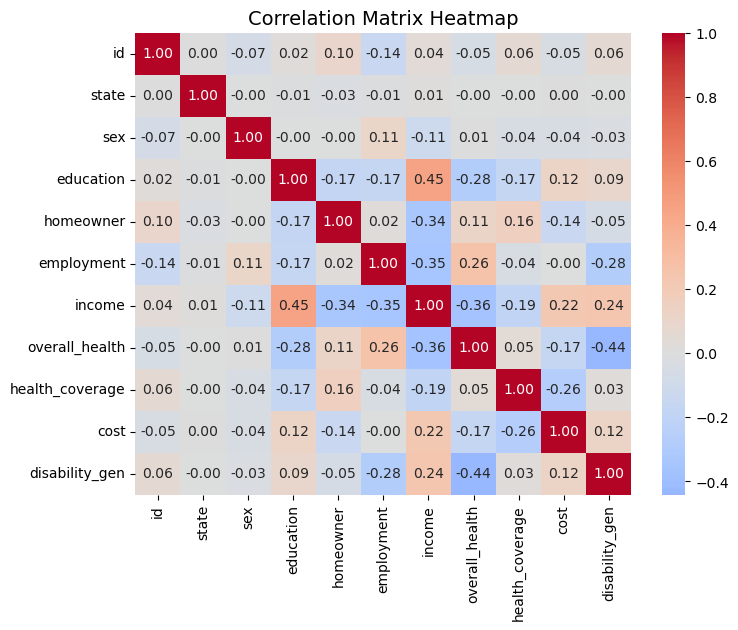

In [5]:
# Correlation Matrix
corr_matrix = df_clean.corr()

# Heatmap of Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.show()

## Conclusions and Recommendations
This analysis demonstrates that socioeconomic and access-related factors significantly influence self-reported health status. Employment, income, cost barriers, and disability status were identified as the most significant predictors of perceived health.

These findings highlight the importance of policies that reduce financial barriers to care and promote equitable employment opportunities. Future analyses could build on this work by utilizing the full BRFSS dataset across multiple years to allow for longitudinal insights. Incorporating additional socioeconomic, social, and geographic variables would further enrich understanding of how social determinants shape self-reported health outcomes.